## Assignment Part4 - Data Visualization & Machine Learning
# Theme #
# Student Performane Analysis & Prediction


In [2]:
# insert the data given assignment data into students.csv file
data = """name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
Alice,88,92,76,80,95,92,4.5,1
Bob,42,55,48,50,60,65,1.2,0
Charlie,75,70,80,68,88,85,3.0,1
Diana,95,98,91,89,97,98,6.0,1
Eve,38,42,50,45,55,58,0.8,0
Frank,60,65,72,58,70,78,2.5,1
Grace,55,48,44,52,62,60,1.5,0
Henry,82,79,85,77,90,88,4.0,1
Iris,70,74,68,65,78,80,3.5,1
Jack,30,35,40,28,45,50,0.5,0
Karen,65,60,70,62,75,72,2.8,1
Liam,48,52,44,55,58,62,1.8,0
Mia,91,94,88,92,96,95,5.5,1
Noah,58,62,55,60,68,70,2.0,0
Olivia,78,75,82,70,85,84,3.8,1
"""

with open("students.csv", "w") as file:
    file.write(data)

print("CSV file created successfully!")

CSV file created successfully!


In [12]:
data = """name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
Alice,88,92,76,80,95,92,4.5,1
Bob,42,55,48,50,60,65,1.2,0
Charlie,75,70,80,68,88,85,3.0,1
Diana,95,98,91,89,97,98,6.0,1
Eve,38,42,50,45,55,58,0.8,0
Frank,60,65,72,58,70,78,2.5,1
Grace,55,48,44,52,62,60,1.5,0
Henry,82,79,85,77,90,88,4.0,1
Iris,70,74,68,65,78,80,3.5,1
Jack,30,35,40,28,45,50,0.5,0
Karen,65,60,70,62,75,72,2.8,1
Liam,48,52,44,55,58,62,1.8,0
Mia,91,94,88,92,96,95,5.5,1
Noah,58,62,55,60,68,70,2.0,0
Olivia,78,75,82,70,85,84,3.8,1
"""

with open("students.csv", "w") as file:
    file.write(data)

print("CSV file created successfully!")

CSV file created successfully!


In [10]:
#______________Task 4.1________________
#Data Exploration With Pandas
import pandas as pd

# Load the dataset
df = pd.read_csv("students.csv")

# Task4.1-1 print the First 5 rows of the dataset
print("********** First 5 rows of the dataset **********")
print(df.head())

# Task4.1-2 Print the shape and datatype of all columns
print("********** Shape of the dataset **********")
print(df.shape)
print("********** Data types of all columns **********")
print(df.dtypes)

# Task4.1-3 Print the summary statistics of all numeric columns
print("********** Summary statistics of numeric columns **********")
print(df.describe())

# Task4.1-4 Print the number of students who passed and failed
print("********** Number of students who passed and failed **********")
print(df['passed'].value_counts())
print("********** Average score per subject for students who passed and failed **********")
print(df.groupby('passed')[['math', 'science', 'english', 'history', 'pe']].mean())

# Task4.1-5 print average score per subject 
print("********** Average score per subject  **********")
passed_students = df[df['passed'] == 1]
failed_students = df[df['passed'] == 0]
# Calculate and print average scores for passed students 
print("Average scores for students who passed:")
print(passed_students[['math', 'science', 'english', 'history', 'pe']].mean())
# Calculate and print average scores for failed students
print("Average scores for students who failed:")
print(failed_students[['math', 'science', 'english', 'history', 'pe']].mean())

# Task4.1-6 print the student who has the highest overall average from all 5 subjects
print("********** Student with the highest overall average score **********")
df['overall_average'] = df[['math', 'science', 'english', 'history', 'pe']].mean(axis=1)
highest_avg_student = df.loc[df['overall_average'].idxmax()]
print(highest_avg_student[['name', 'overall_average']])


********** First 5 rows of the dataset **********
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  
********** Shape of the dataset **********
(15, 9)
********** Data types of all columns **********
name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
pa

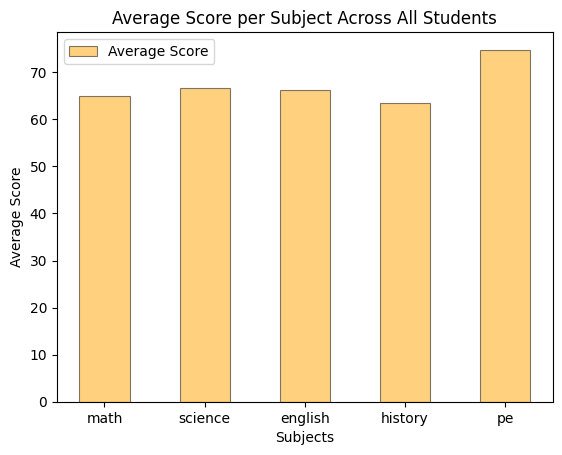

In [21]:
#______________Task 4.2________________
#Data Visualization With Matplotlib
import matplotlib.pyplot as plt

# add a new column to the dataframe that calculates the average score across all 5 subjects for each student
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)


# Task4.2-1 Create a bar chart showing (X-axis: student names, Y-axis: average score

# Create avg_score column (as required)
df['avg_score'] = df[subject_cols].mean(axis=1)

# Calculate average score per subject
avg_scores = df[subject_cols].mean()

# Create bar chart
plt.figure()
plt.bar(subject_cols, avg_scores, label="Average Score", color='orange', edgecolor='black', linewidth=0.8, alpha=0.5, hatch='', width=0.5)

# Labels and title
plt.title("Average Score per Subject Across All Students")
plt.xlabel("Subjects")
plt.ylabel("Average Score")
plt.legend()

# Save and show
plt.savefig("plot1_bar.png")
plt.show()


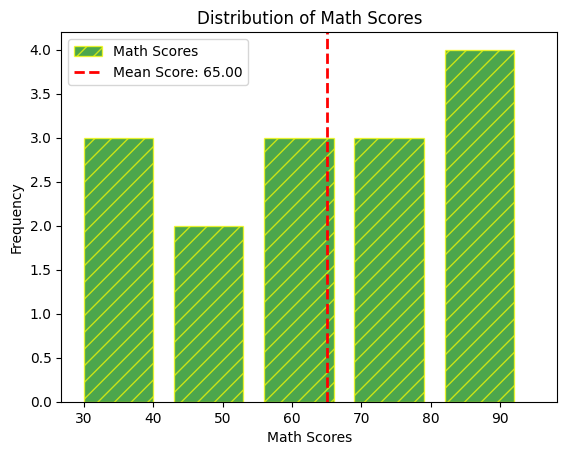

In [30]:
# Task4.2-2 Create a Histogram for distribution of math scores using 5 bins
# Vertical dashline at the mean math score
# Create histogram for math scores
plt.figure()
plt.hist(df['math'], bins=5, edgecolor='yellow', label="Math Scores", color='green', alpha=0.7, hatch='//', width=10)
# Add vertical dashed line at mean math score
mean_math_score = df['math'].mean()
plt.axvline(mean_math_score, color='red', linestyle='dashed', linewidth=2, label=f'Mean Score: {mean_math_score:.2f}')
# Labels and title
plt.title("Distribution of Math Scores")
plt.xlabel("Math Scores")
plt.ylabel("Frequency")
plt.legend()
# Save and show
plt.savefig("plot2_histogram.png")
plt.show()


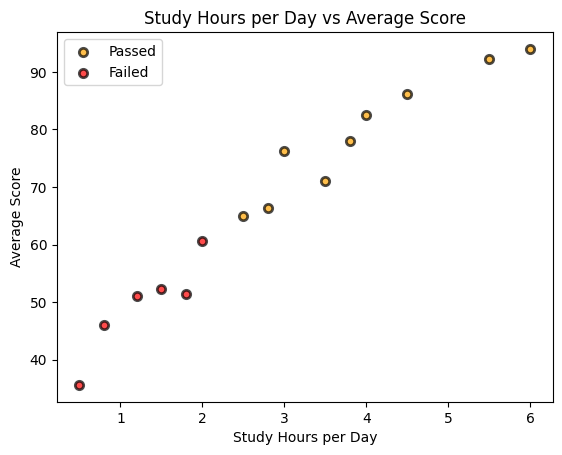

In [34]:
# Task4.2-3 Create a Scatter plot 
# Scatter plot for study hours per day vs average score with different color for passed and failed students using legends using two groups separately

# Assuming you have a column 'passed' (1 for passed, 0 for failed)
passed_students = df[df['passed'] == 1]
failed_students = df[df['passed'] == 0]
plt.figure()
plt.scatter(passed_students['study_hours_per_day'], passed_students['avg_score'], color='orange', label='Passed', alpha=0.7, edgecolor='black', linewidth=2, )
plt.scatter(failed_students['study_hours_per_day'], failed_students['avg_score'], color='red', label='Failed', alpha=0.7, edgecolor='black', linewidth=2, )

plt.title("Study Hours per Day vs Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.legend()
plt.savefig("plot3_scatter.png")
plt.show()


C:\Users\kushs\AppData\Local\Temp\ipykernel_13168\3985172320.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'], patch_artist=True,


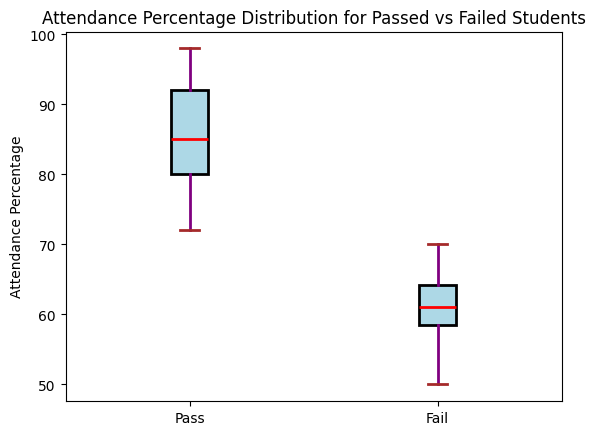

In [ ]:
# Task4.2-4 Create a box plot 
# Box plot for passed and failed students attendace distribution side by side with different colors and legends

plt.figure()
pass_attendance = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attendance = df[df['passed'] == 0]['attendance_pct'].tolist()
plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'], patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='Black', linewidth=2),
            medianprops=dict(color='red', linewidth=2),
            whiskerprops=dict(color='Purple', linewidth=2),
            capprops=dict(color='brown', linewidth=2))
plt.title("Attendance Percentage Distribution for Passed vs Failed Students")
plt.ylabel("Attendance Percentage")
plt.savefig("plot4_box.png")
plt.show()


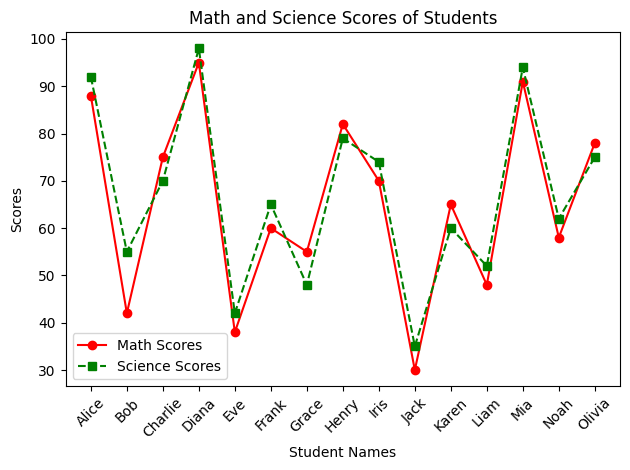

In [ ]:
# Task4.2-5 Create a Line plot 
# Line Plot for math and science Scores of every Students
plt.figure()
plt.plot(df['name'], df['math'], marker='o', linestyle='-', color='Red', label='Math Scores')
plt.plot(df['name'], df['science'], marker='s', linestyle='--', color='green', label='Science Scores')
plt.xticks(rotation=45)
plt.title("Math and Science Scores of Students")
plt.xlabel("Student Names")
plt.ylabel("Scores")
plt.legend()
plt.tight_layout()
plt.savefig("plot5_line.png")
plt.show()


C:\Users\kushs\AppData\Local\Temp\ipykernel_13168\1067690735.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='passed', y='math', ax=ax1, palette='Set2',legend=False, edgecolor='black', linewidth=2, alpha=0.7, hatch='//', width=1)
C:\Users\kushs\AppData\Local\Temp\ipykernel_13168\1067690735.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='passed', y='science', ax=ax2, palette='Set2',legend=False, edgecolor='black', linewidth=2, alpha=0.7, hatch='//', width=1)


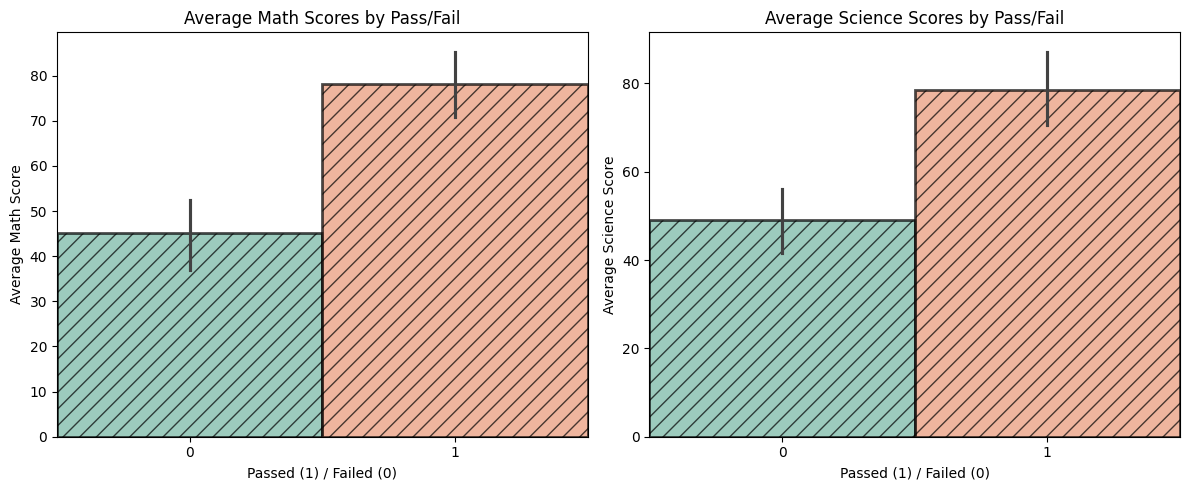

In [45]:
#______________Task 4.3________________
#Data Visualization with Seaborn
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(12, 5))
ax1 = plt.subplot(1, 2, 1)
sns.barplot(data=df, x='passed', y='math', ax=ax1, palette='Set2',legend=False, edgecolor='black', linewidth=2, alpha=0.7, hatch='//', width=1)
ax1.set_title("Average Math Scores by Pass/Fail")
ax1.set_xlabel("Passed (1) / Failed (0)")
ax1.set_ylabel("Average Math Score")
ax2 = plt.subplot(1, 2, 2)
sns.barplot(data=df, x='passed', y='science', ax=ax2, palette='Set2',legend=False, edgecolor='black', linewidth=2, alpha=0.7, hatch='//', width=1)
ax2.set_title("Average Science Scores by Pass/Fail")
ax2.set_xlabel("Passed (1) / Failed (0)")
ax2.set_ylabel("Average Science Score")
plt.tight_layout()
plt.savefig("plot6_seaborn_bar.png")
plt.show()


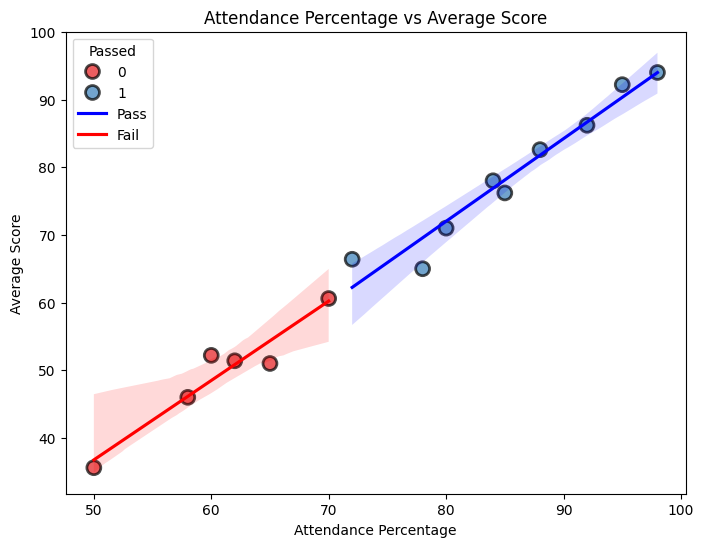

In [ ]:
# Task4.3-2 Create a seaborn Scatter Plot
# Seaborn Scatter plot for attendance and avg score coloured by passed
#Add a regression line for each group (Pass and Fail) on the same axes.

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed', palette='Set1', edgecolor='black', linewidth=2, alpha=0.7, s=100)
sns.regplot(data=df[df['passed'] == 1], x='attendance_pct', y='avg_score', scatter=False, label='Pass', color='blue')
sns.regplot(data=df[df['passed'] == 0], x='attendance_pct', y='avg_score', scatter=False, label='Fail', color='red')
plt.title("Attendance Percentage vs Average Score")
plt.xlabel("Attendance Percentage")
plt.ylabel("Average Score")
plt.legend(title='Passed')
plt.savefig("plot7_seaborn_scatter.png")
plt.show()


In [ ]:
# Task4.3-3 
# Save both Seaborn Chart as plot6_seaborn_bar.png and plot7_seaborn_scatter.png in the current directory. (Already done in above code)

In [ ]:
# Task4.3-4 Write Experience Of using matplotlib and seaborn for data visualization in python in 2-3 lines


# *************************************Matplotlib*******************************************
# Matplotlib provides a lot of flexibility and control over the appearance of plots, making it great for custom visualizations. 
# Matplotlib Requires more effort in terms of writing more lines of code 
# *************************************Seaborn***********************************************
# Seaborn, on the other hand, for category wise distribution it is more simpler in seaborn,as it is automatically grouping and with less code gives attractive visuals 
# higher-level interface to make informative and more interactive with less code , so for that seaborn is ideal for great visuals

In [4]:
#__________Task 4.4____________
# Machine Learning With Scikit Learn 

# Task 4.4-1 Prepare The data classification model 

# Classifier to predict whether a student will pass or fail 
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the dataset
df = pd.read_csv("students.csv")

# Prepare the data
X = df[['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']]
y = df['passed']

# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Sacale the features using StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [8]:
# Task4.4-2 Train a Model

# train logisticregressioin model on scaled training data
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

# Print statements to check model accuracy on training data
train_accuracy = model.score(X_train, y_train)
print("*********** Model Training **********")
print("Model trained successfully!")
print("Training Accuracy: ", train_accuracy)
print("Model intercept: ", model.intercept_) 
print("********************************************")


*********** Model Training **********
Model trained successfully!
Training Accuracy:  1.0
Model intercept:  [1.82148644]
********************************************


In [ ]:
# Task 4.4-3 Evaluate the model on test data
# Prediction
y_pred = model.predict(X_test)

# Test Accuracy for y-test and prdiction
from sklearn.metrics import accuracy_score

# print the Test accuracy for tast accuracy
Test_accuracy = accuracy_score(y_test,y_pred)
print("***********Test Accuracy***********")
print(f"Test Accuracy: {Test_accuracy:.2f}")
print("***********************************")

# check the model is correct for each student with actual and predict labled
print("************ Test Results**************")
for idx, actual, pred in zip(y_test.index, y_test, y_pred):
    name = df.loc[idx, 'name']
    result = "✅ Correct" if actual == pred else "❌ Wrong"
    print(f"{name}: Actual={actual}, Predicted={pred} → {result}")




      



***********Test Accuracy***********
Test Accuracy: 1.00
***********************************
************ Test Results**************


AttributeError: 'numpy.ndarray' object has no attribute 'index'